In [1]:
%%capture --no-stderr
%pip install -U langgraph langsmith

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [1]:
import getpass
import os
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_API_KEY"] = "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"

In [2]:
from dotenv import load_dotenv
import os
load_dotenv()



from langchain_openai import AzureChatOpenAI

model = AzureChatOpenAI(

    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"],
    openai_api_version=os.environ["AZURE_OPENAI_API_VERSION"],
)

In [5]:
def chatbot(state: State):
    return {"messages": [model.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

In [6]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

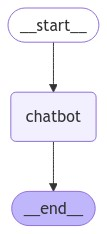

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [8]:
# while True:
#     user_input = input("User: ")
#     if user_input.lower() in ["quit", "exit", "q"]:
#         print("Goodbye!")
#         break
#     for event in graph.stream({"messages": ("user", user_input)}):
#         for value in event.values():
#             print("Assistant:", value["messages"][-1].content)
for event in graph.stream({"messages": ("user", "tell me a joke")}):
    for value in event.values():
        print(value["messages"][-1].content)

Sure, here's one for you:

Why don't skeletons fight each other?

They don't have the guts!


## Enhancing the Chatbot with Tools

In [ ]:
# Enhancing the Chatbot with Tools
%pip install -U tavily-python
%pip install -U langchain_community


In [12]:
load_dotenv()

True

In [6]:
from langchain_community.tools.tavily_search import TavilySearchResults

tool = TavilySearchResults(max_results=2)
tools = [tool]
tool.invoke("What's a 'node' in LangGraph?")
# 

[{'url': 'https://langchain-ai.github.io/langgraph/concepts/low_level/',
  'content': 'Nodes¶ In LangGraph, nodes are typically python functions (sync or async) where the first positional argument is the state, and (optionally), the second positional argument is a "config", containing optional configurable parameters (such as a thread_id). Similar to NetworkX, you add these nodes to a graph using the add_node method:'},
 {'url': 'https://medium.com/@kbdhunga/langgraph-multi-agent-collaboration-explained-c0500b0f2e61',
  'content': 'Nodes: Nodes in LangGraph represent individual units of computation or functionality within a graph. Nodes can be functions or runnables that perform specific tasks or operations.'}]

In [8]:


# Modification: tell the LLM which tools it can call
llm_with_tools = model.bind_tools(tools)

def chatbot_with_tools(state: State):
    return {"messages": [model.invoke(state["messages"])]}

# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot_with_tools)


In [9]:
import json

from langchain_core.messages import ToolMessage


class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        # 检查是否存在名为 "messages" 的输入字段，如果有则赋值给 messages 变量
        if messages := inputs.get("messages", []):
        # 获取 messages 列表的最后一个元素并赋值给 message 变量
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
        outputs = []
        # 遍历 message 中的 tool_calls 列表,这里与普通tool调用类似
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

In [10]:
#add tools_condition to choose the tools
from typing import Literal


def route_tools(
    state: State,
) -> Literal["tools", "__end__"]:
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    # 判断是否有工具调用
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return "__end__"


# The `tools_condition` function returns "tools" if the chatbot asks to use a tool, and "__end__" if
# it is fine directly responding. This conditional routing defines the main agent loop.
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    # The following dictionary lets you tell the graph to interpret the condition's outputs as a specific node
    # It defaults to the identity function, but if you
    # want to use a node named something else apart from "tools",
    # You can update the value of the dictionary to something else
    # e.g., "tools": "my_tools"
    {"tools": "tools", "__end__": "__end__"},
)
# Any time a tool is called, we return to the chatbot to decide the next step
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")
# tool 调用包含了end的情况,所以不需要再添加end的node
graph = graph_builder.compile()


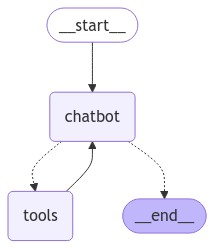

In [11]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

## Adding Memory to the Chatbot

In [12]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [13]:
graph = graph_builder.compile(checkpointer=memory)

In [14]:
# 定义一个线程
config = {"configurable": {"thread_id": "1"}}
user_input = "Hi there! My name is Will."

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Hi there! My name is Will.
================================== Ai Message ==================================

Hello, Will! How can I assist you today?


In [15]:
# 测试是否memory
user_input = "Remember my name?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Remember my name?
================================== Ai Message ==================================

Sure, I'll remember your name is Will. How can I help you today, Will?


In [16]:
# 检查config
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Hi there! My name is Will.', id='ed351de6-7a5c-46dc-85c1-02daeea02df3'), AIMessage(content='Hello, Will! How can I assist you today?', response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 15, 'total_tokens': 26}, 'model_name': 'gpt-4o-2024-05-13', 'system_fingerprint': 'fp_80a1bad4c7', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}, id='run-4a153317-0791-4741-a783-34647ea48926-0', usage_metadata={'inpu

In [17]:
snapshot.next  
# (since the graph ended this turn, `next` is empty. If you fetch a state from within a graph invocation, next tells which node will execute next)

()

## Human-in-the-loop

In [3]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

memory = MemorySaver()


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


tool = TavilySearchResults(max_results=2)
tools = [tool]
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(

    azure_deployment=os.environ["AZURE_OPENAI_DEPLOYMENT_NAME"],
    openai_api_version=os.environ["AZURE_OPENAI_API_VERSION"],
)
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

In [5]:
graph = graph_builder.compile(
    checkpointer=memory,
    # This is new!
    interrupt_before=["tools"],
    # Note: can also interrupt __after__ tools, if desired.
    # interrupt_after=["tools"]
)

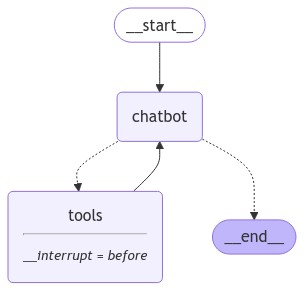

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [7]:
user_input = "I'm learning LangGraph. Could you do some research on it for me?"
config = {"configurable": {"thread_id": "1"}}
# 因为设置了interrupt_before,所以在配置中如果有memory,则会中断tools
# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]}, config, stream_mode="values"
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I'm learning LangGraph. Could you do some research on it for me?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_aCeMcYwL8fJgBRzxMeKESL25)
 Call ID: call_aCeMcYwL8fJgBRzxMeKESL25
  Args:
    query: LangGraph programming language


In [8]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [9]:
existing_message = snapshot.values["messages"][-1]
existing_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'LangGraph programming language'},
  'id': 'call_aCeMcYwL8fJgBRzxMeKESL25',
  'type': 'tool_call'}]

In [10]:
# `None` will append nothing new to the current state, letting it resume as if it had never been interrupted
events = graph.stream(None, config, stream_mode="values")
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_aCeMcYwL8fJgBRzxMeKESL25)
 Call ID: call_aCeMcYwL8fJgBRzxMeKESL25
  Args:
    query: LangGraph programming language
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141", "content": "3. LangGraph is a powerful tool for building stateful, multi-actor applications with Large Language Models (LLMs). It extends the LangChain library, allowing you to coordinate multiple chains (or ..."}, {"url": "https://www.datacamp.com/tutorial/langgraph-tutorial", "content": "LangGraph can be used to build a wide range of applications. Chatbots. LangGraph is ideal for developing sophisticated chatbots that can handle a wide array of user requests. By leveraging multiple LLM agents, these chatbots can process natural language q

## Manually Updating the State

In [11]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]
existing_message.pretty_print()

================================== Ai Message ==================================

Here are a couple of resources to get you started with LangGraph:

1. [Introduction to LangGraph: A Beginner's Guide](https://medium.com/@cplog/introduction-to-langgraph-a-beginners-guide-14f9be027141)
   - This article explains that LangGraph is a powerful tool for building stateful, multi-actor applications with Large Language Models (LLMs). It extends the LangChain library, allowing you to coordinate multiple chains.

2. [LangGraph Tutorial on DataCamp](https://www.datacamp.com/tutorial/langgraph-tutorial)
   - This tutorial covers the use of LangGraph in building a wide range of applications, including sophisticated chatbots that can handle a variety of user requests. By leveraging multiple LLM agents, these chatbots can process natural language queries, provide accurate responses, and switch between different conversation contexts seamlessly.

These resources should help you understand the fundamenta